Using device: cuda
Train size: 58438, Val size: 12523, Test size: 12523


model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Epoch [1/10], Train Loss: 0.6679, Train Acc: 0.7552, Val Loss: 0.2833, Val Acc: 0.9090
Epoch [2/10], Train Loss: 0.2602, Train Acc: 0.9115, Val Loss: 0.2438, Val Acc: 0.9136
Epoch [3/10], Train Loss: 0.2184, Train Acc: 0.9263, Val Loss: 0.2091, Val Acc: 0.9307
Epoch [4/10], Train Loss: 0.2022, Train Acc: 0.9311, Val Loss: 0.2066, Val Acc: 0.9301
Epoch [5/10], Train Loss: 0.1922, Train Acc: 0.9352, Val Loss: 0.1854, Val Acc: 0.9367
Epoch [6/10], Train Loss: 0.1852, Train Acc: 0.9381, Val Loss: 0.1742, Val Acc: 0.9403
Epoch [7/10], Train Loss: 0.1778, Train Acc: 0.9395, Val Loss: 0.1715, Val Acc: 0.9438
Epoch [8/10], Train Loss: 0.1733, Train Acc: 0.9417, Val Loss: 0.1634, Val Acc: 0.9447
Epoch [9/10], Train Loss: 0.1701, Train Acc: 0.9428, Val Loss: 0.1625, Val Acc: 0.9449
Epoch [10/10], Train Loss: 0.1641, Train Acc: 0.9439, Val Loss: 0.1616, Val Acc: 0.9457
Model saved to mobilenetv3_small_classifier.pth

Classification Report:
               precision    recall  f1-score   support

 

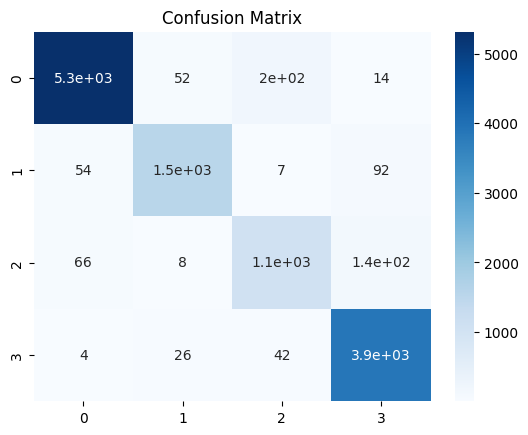

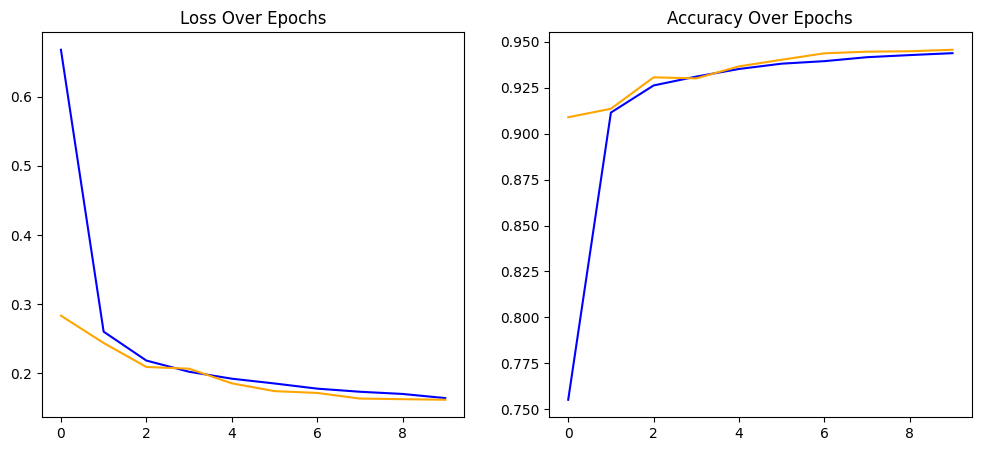

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------
# 🚀 Device Configuration
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------
# 📂 Data Preprocessing & Dataloaders (Same Preprocessing for Fair Comparison)
# ----------------------
dataset_path = "/kaggle/input/kermany2018/OCT2017 "
train_dir, val_dir, test_dir = os.path.join(dataset_path, 'train'), os.path.join(dataset_path, 'val'), os.path.join(dataset_path, 'test')

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomRotation(15),  
    transforms.RandomAffine(degrees=15, shear=10),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  
])

train_dataset_full = datasets.ImageFolder(root=train_dir, transform=image_transform)
val_dataset_from_val_folder = datasets.ImageFolder(root=val_dir, transform=image_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=image_transform)

# Adjust train-test split (70-15-15)
train_indices, temp_indices = train_test_split(
    np.arange(len(train_dataset_full)),
    test_size=0.3,
    stratify=train_dataset_full.targets,
    random_state=42
)

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    stratify=[train_dataset_full.targets[i] for i in temp_indices],
    random_state=42
)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(train_dataset_full, val_indices)
test_dataset = Subset(train_dataset_full, test_indices)

# DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train size: {len(train_loader.dataset)}, Val size: {len(val_loader.dataset)}, Test size: {len(test_loader.dataset)}")

# ----------------------
# 🏗 MobileNetV3-Small Model (Lower Accuracy)
# ----------------------

class MobileNetV3SmallClassifier(nn.Module):
    """MobileNetV3-Small Model for Retinal OCT Classification"""
    def __init__(self, num_classes):
        super().__init__()
        self.mobilenet = timm.create_model("mobilenetv3_small_100", pretrained=True, num_classes=num_classes)
        self.dropout = nn.Dropout(0.4)  

    def forward(self, x):
        x = self.mobilenet(x)
        return self.dropout(x)

# ----------------------
# 💾 Model Saving & Loading
# ----------------------

def save_model(model, optimizer, filename="mobilenetv3_small_classifier.pth"):
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, filename)
    print(f"Model saved to {filename}")

def load_model(filename="mobilenetv3_small_classifier.pth"):
    model = MobileNetV3SmallClassifier(num_classes=len(train_dataset_full.classes)).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)  
    
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"Model loaded from {filename}")
    return model, optimizer

# ----------------------
# 🔥 Training
# ----------------------
num_classes = len(train_dataset_full.classes)
model = MobileNetV3SmallClassifier(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

def train_model(model, train_loader, val_loader, num_epochs=10):  
    model.train()
    for epoch in range(num_epochs):
        train_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            correct_train += predicted.eq(labels).sum().item()
            total_train += labels.size(0)

        train_acc = correct_train / total_train
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                correct_val += predicted.eq(labels).sum().item()
                total_val += labels.size(0)

        val_acc = correct_val / total_val
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

train_model(model, train_loader, val_loader, num_epochs=10)
save_model(model, optimizer)

# ----------------------
# 🏆 Final Evaluation & Graphs
# ----------------------
def plot_loss_accuracy():
    """Plots Training & Validation Loss and Accuracy"""
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='orange')
    plt.title('Loss Over Epochs')

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy', color='blue')
    plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
    plt.title('Accuracy Over Epochs')
    plt.show()

def evaluate_model(model, loader):
    """Confusion Matrix + Classification Report"""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(model, test_loader)
plot_loss_accuracy()